# Solar curtailment in the Brazilian grid (SIN): exploratory analysis

Data: the `terra_br` database (local PostGIS), `clean` schema built by `sql/10_clean.sql` on top of the
ONS photovoltaic curtailment files (Apr 2024–Aug 2026), the ANEEL plant register and the basic
transmission network. Database setup: `docs/postgis.md`.

**Definitions used throughout**
- *Reference generation*: what the cluster would have generated without curtailment, estimated by ONS.
- *Curtailment*: `reference − generation`, only in intervals where ONS recorded a reason (`ENE`, `CNF`,
  `REL`) and the reference is valid (`clean.pv_curtail.curtailed_mw`).
- *Curtailed share*: `curtailment / (generation + curtailment)`, the fraction of possible generation that
  was not generated.
- *Energy*: values are 30-min average powers in MW; summed and divided by 2,000 they give GWh.

Figures are written to `reports/figures/` (PDF, SVG and PNG) by `viz.save`.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from terra_energy_research import viz
from terra_energy_research.db import engine, query

viz.setup()
pd.set_option("display.float_format", "{:,.1f}".format)

MW_HALFHOUR_TO_GWH = 1 / 2000  # sum of 30-min powers (MW) -> energy (GWh)

## 1. Data quality

One row per check in the `clean` layer. Physically impossible values were set to `NULL`; the originals
remain in the `*_raw` columns.

In [2]:
query("select * from clean.quality_summary")

,source,issue,n
0,plant,operation_start = 1900-01-03,"2,485.0"
1,plant,capacity_kw null or <= 0,"2,341.0"
2,plant,geometry missing or outside Brazil,433.0
3,transmission_line,length over_3x_straight,21.0
4,transmission_line,length shorter_than_straight,103.0
5,transmission_line,length missing,11.0
6,transmission_line,capacity_mva null,939.0
7,pv_curtail,id_ons not registered in ons_unit,4.0
8,pv_curtail,cluster_key null (rows),"169,536.0"
9,pv_curtail,subsystem differs from ons_unit (rows),"1,008.0"


## 2. Monthly curtailment

Generated energy, curtailed energy and curtailment by reason, summed per month over all clusters.

In [3]:
monthly = query("""
    select date_trunc('month', instante)::date                         as month,
           sum(generation)                                             as generation,
           sum(curtailed_mw)                                           as curtailment,
           sum(curtailed_mw) filter (where reason_code = 'ENE')        as "ENE",
           sum(curtailed_mw) filter (where reason_code = 'CNF')        as "CNF",
           sum(curtailed_mw) filter (where reason_code = 'REL')        as "REL"
    from clean.pv_curtail
    group by 1
    order by 1
""")
monthly["month"] = pd.to_datetime(monthly["month"])
energy_columns = ["generation", "curtailment", "ENE", "CNF", "REL"]
monthly[energy_columns] = monthly[energy_columns].fillna(0) * MW_HALFHOUR_TO_GWH
monthly["curtailed_share"] = 100 * monthly["curtailment"] / (monthly["generation"] + monthly["curtailment"])

monthly.set_index(monthly["month"].dt.strftime("%Y-%m")).drop(columns="month")

,generation,curtailment,ENE,CNF,REL,curtailed_share
month,,,,,,
2024-04,"2,106.1",62.1,41.8,18.2,2.1,2.9
2024-05,"2,114.2",192.5,101.8,86.4,4.3,8.3
2024-06,"1,941.3",272.2,139.9,117.1,15.2,12.3
2024-07,"2,080.1",395.1,77.5,236.0,81.7,16.0
2024-08,"2,369.2",457.0,96.8,288.0,72.3,16.2
2024-09,"2,425.5",628.4,229.0,331.4,68.0,20.6
2024-10,"2,687.3",398.2,226.0,154.0,18.3,12.9
2024-11,"2,633.6",341.9,185.9,126.8,29.2,11.5
2024-12,"2,697.0",497.8,452.7,36.5,8.7,15.6


In [4]:
# Annual totals (2024 starts in April and 2026 ends in August)
annual = monthly.groupby(monthly["month"].dt.year)[energy_columns].sum()
annual["curtailed_share"] = 100 * annual["curtailment"] / (annual["generation"] + annual["curtailment"])
annual["ENE_share_of_curtailment"] = 100 * annual["ENE"] / annual["curtailment"]
annual

,generation,curtailment,ENE,CNF,REL,curtailed_share,ENE_share_of_curtailment
month,,,,,,,
2024,"21,054.2","3,245.1","1,551.2","1,394.3",299.6,13.4,47.8
2025,"31,719.4","10,997.0","6,700.3","2,845.5","1,451.2",25.7,60.9
2026,"24,352.8","7,978.9","6,742.1",567.1,669.7,24.7,84.5


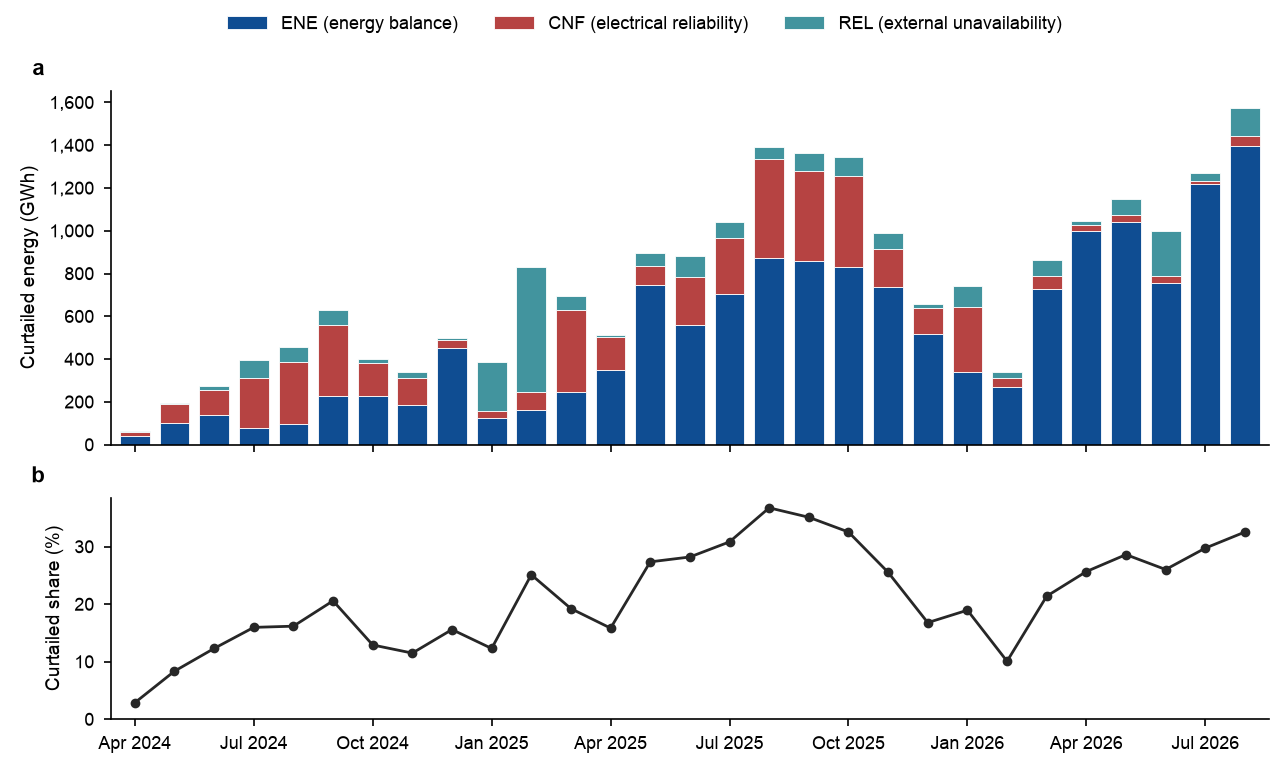

In [5]:
fig, (ax_energy, ax_share) = plt.subplots(
    2, 1, figsize=viz.size(height_mm=95), sharex=True, height_ratios=[1.6, 1], layout="constrained")
months = np.arange(len(monthly))

# a: curtailed energy by reason, stacked bars
bottom = np.zeros(len(monthly))
for reason in ("ENE", "CNF", "REL"):
    ax_energy.bar(months, monthly[reason], bottom=bottom, width=0.75, color=viz.REASON_COLORS[reason],
                  label=viz.REASON_LABELS[reason], edgecolor="white", linewidth=0.3)
    bottom += monthly[reason].to_numpy()
ax_energy.set_ylabel("Curtailed energy (GWh)")
viz.comma_axis(ax_energy.yaxis)

# b: curtailed share
ax_share.plot(months, monthly["curtailed_share"], color=viz.COLORS["black"], marker="o", markersize=2.5)
ax_share.set_ylim(0, None)
ax_share.set_ylabel("Curtailed share (%)")
viz.month_axis(ax_share, monthly["month"])

for ax, letter in ((ax_energy, "a"), (ax_share, "b")):
    viz.panel_label(ax, letter)
fig.legend(*ax_energy.get_legend_handles_labels(), loc="outside upper center", ncols=3)
viz.save(fig, "fig1_monthly_curtailment")

**Figure 1 | Solar curtailment grew from Apr 2024 to Aug 2026, and energy-balance (ENE) curtailment
became the largest component.** **a**, Curtailed energy per month, stacked by the reason recorded by
ONS. **b**, Curtailed share per month, `curtailment / (generation + curtailment)`. All ONS photovoltaic
clusters; n = 29 months. Annual values in the table above.

## 3. When curtailment happens: hour × weekday

Curtailed share by hour of day and day of the week, over the whole period. Only 6:00–17:59, when
generation is relevant.

In [6]:
profile = query("""
    select extract(isodow from instante)::int as weekday,     -- 1 = Monday
           extract(hour from instante)::int   as hour,
           100 * sum(curtailed_mw) / nullif(sum(generation) + sum(curtailed_mw), 0) as curtailed_share
    from clean.pv_curtail
    where extract(hour from instante) between 6 and 17
    group by 1, 2
""")
hour_by_weekday = profile.pivot(index="weekday", columns="hour", values="curtailed_share")
hour_by_weekday.round(0)

hour,6,7,8,9,10,11,12,13,14,15,16,17
weekday,,,,,,,,,,,,
1,8.0,17.0,22.0,24.0,24.0,22.0,21.0,15.0,9.0,6.0,3.0,1.0
2,8.0,18.0,22.0,24.0,24.0,22.0,21.0,15.0,9.0,6.0,3.0,2.0
3,9.0,19.0,23.0,25.0,25.0,23.0,22.0,16.0,9.0,6.0,3.0,1.0
4,10.0,19.0,25.0,26.0,26.0,24.0,23.0,16.0,10.0,6.0,4.0,2.0
5,8.0,17.0,23.0,25.0,25.0,23.0,21.0,15.0,10.0,6.0,5.0,3.0
6,13.0,26.0,33.0,36.0,37.0,36.0,33.0,26.0,18.0,12.0,6.0,2.0
7,22.0,42.0,52.0,58.0,61.0,58.0,53.0,46.0,34.0,19.0,7.0,1.0


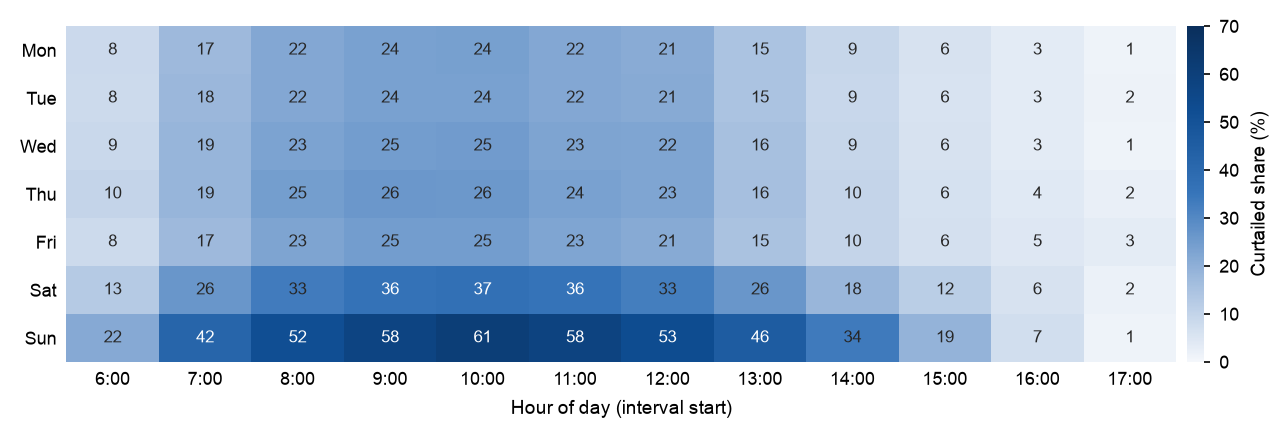

In [7]:
fig, ax = plt.subplots(figsize=viz.size(height_mm=52), layout="constrained")
values = hour_by_weekday.to_numpy()
image = ax.imshow(values, cmap=viz.SEQUENTIAL, aspect="auto", vmin=0, vmax=np.ceil(values.max() / 10) * 10)

ax.set_yticks(range(7), viz.WEEKDAYS)
ax.set_xticks(range(values.shape[1]), [f"{h}:00" for h in hour_by_weekday.columns])
ax.set_xlabel("Hour of day (interval start)")
ax.tick_params(length=0)
for side in ("left", "bottom"):
    ax.spines[side].set_visible(False)

# value of each cell; white text on dark cells
for (row, col), value in np.ndenumerate(values):
    ax.text(col, row, viz.num(value), ha="center", va="center", fontsize=6,
            color="white" if value > 0.55 * values.max() else viz.COLORS["black"])

colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.01)
colorbar.outline.set_visible(False)
colorbar.ax.tick_params(width=0.6, length=2)
colorbar.set_label("Curtailed share (%)")
viz.save(fig, "fig2_hour_weekday")

**Figure 2 | Curtailment concentrates in the late morning and on weekends.** Curtailed share,
`curtailment / (generation + curtailment)`, by hour of day and day of the week, summed over all
clusters and the whole period (Apr 2024–Aug 2026). Hours 6:00–17:00; each hour combines its two
30-min intervals.

## 4. Where: clusters and the grid

Generated and curtailed energy per cluster, with the coordinate of its connection point (`br.ons_unit`).

In [8]:
units = gpd.read_postgis("""
    select c.id_ons,
           max(c.name)       as name,
           max(c.uf)         as uf,
           max(c.subsystem)  as subsystem,
           sum(c.generation)   / 2000 as generation_gwh,
           sum(c.curtailed_mw) / 2000 as curtailment_gwh,
           100 * sum(c.curtailed_mw) / nullif(sum(c.generation) + sum(c.curtailed_mw), 0) as curtailed_share,
           100 * sum(c.curtailed_mw) filter (where c.origin_code = 'LOC') / nullif(sum(c.curtailed_mw), 0)
                                  as local_origin_share,
           u.geom_connection  as geom
    from clean.pv_curtail c
    left join br.ons_unit u using (id_ons)
    group by c.id_ons, u.geom_connection
""", engine(), geom_col="geom")
units["label"] = units["name"].map(viz.unit_label)

units.drop(columns="geom").sort_values("curtailment_gwh", ascending=False).head(20).reset_index(drop=True)

,id_ons,name,uf,subsystem,generation_gwh,curtailment_gwh,curtailed_share,local_origin_share,label
0,CJU_MGJAN,Conj. Janaúba,MG,SE,"5,382.4","1,885.2",25.9,8.5,Janaúba
1,CJU_MGARN,Conj. Arinos 2 500 kV,MG,SE,"4,784.3","1,189.4",19.9,8.9,Arinos 2 500 kV
2,CJU_MGVST1,Conj. Vista Alegre - Janaúba,MG,SE,"2,595.8","1,016.2",28.1,6.7,Vista Alegre - Janaúba
3,CJU_BASSD,Conj. Sol do Sertão,BA,NE,"1,668.0",888.5,34.8,1.1,Sol do Sertão
4,CJU_PI5FGID,Conj. Gilbués II 500 kV,PI,NE,"2,488.1",784.5,24.0,2.3,Gilbués II 500 kV
5,CJU_BABRD,Conj. Barreiras II 500 kV,BA,NE,"1,253.9",746.8,37.3,6.1,Barreiras II 500 kV
6,CJU_BAFFUT,Conj. Futura,BA,NE,"3,336.5",730.5,18.0,0.7,Futura
7,CJU_MGSDC,Conj. Sol do Cerrado,MG,SE,"2,419.4",726.2,23.1,10.5,Sol do Cerrado
8,CJU_MGSDJ,Conj. Jaíba V,MG,SE,"1,985.9",700.1,26.1,10.6,Jaíba V
9,CJU_RNSDMC,Conj. Serra do Mel C,RN,NE,"2,354.5",649.6,21.6,25.7,Serra do Mel C


In [9]:
transmission = gpd.read_postgis(
    "select voltage_kv, geom from clean.transmission_line where in_service", engine(), geom_col="geom")
located = units.dropna(subset=["geom"])
print(f"{len(units)} clusters; {len(units) - len(located)} without coordinates are left off the map")

87 clusters; 7 without coordinates are left off the map


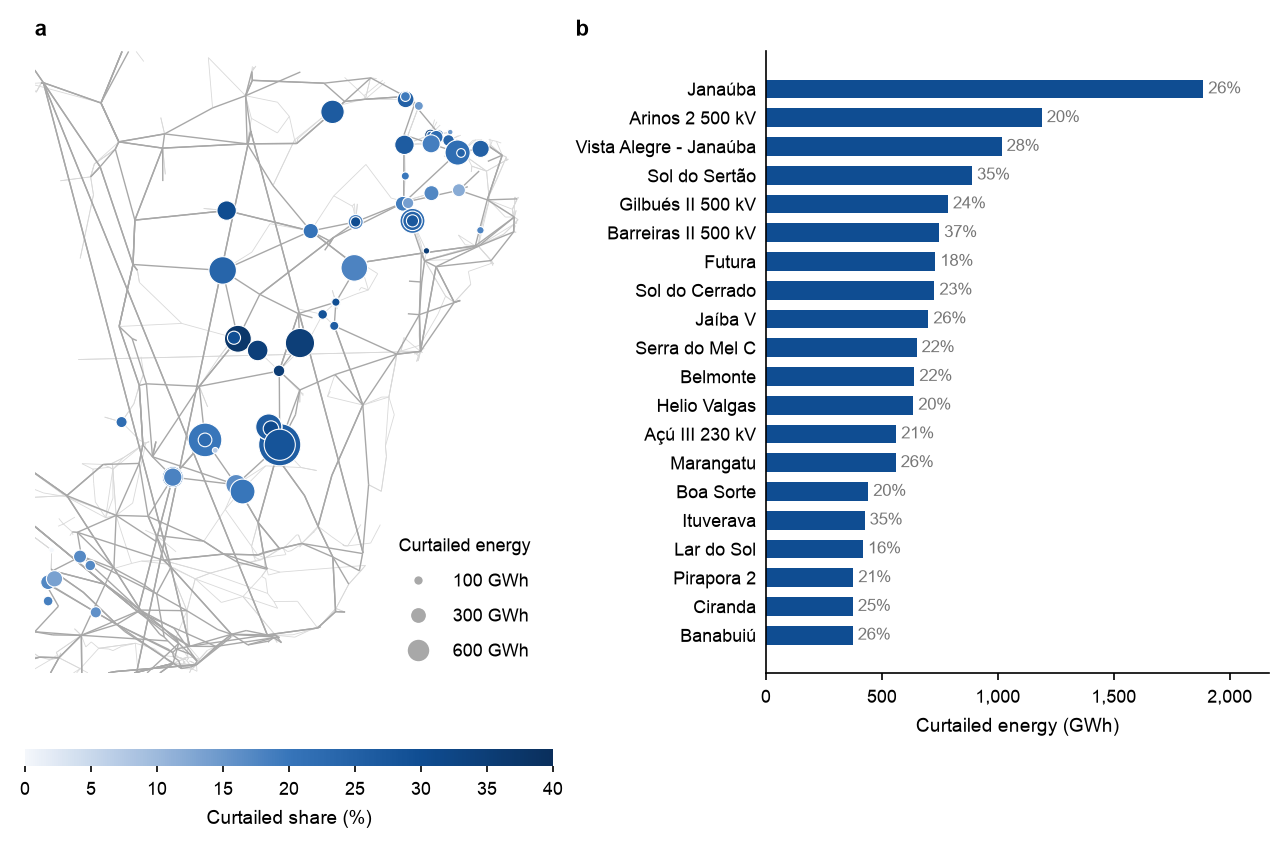

In [10]:
fig = plt.figure(figsize=viz.size(height_mm=100), layout="constrained")
ax_map, ax_top = fig.subplots(1, 2, width_ratios=[1.05, 1])

# a: map. Basic network in grey (darker: ≥ 440 kV); circle = cluster, area ∝ curtailed GWh, color = curtailed share
MAP_EXTENT = (-52, -24, -34, -2)  # west, south, east, north (degrees)
# clip the network to the map area: outside it, lines would stay in the PDF, only hidden
transmission = transmission.clip(MAP_EXTENT)
transmission[transmission["voltage_kv"] < 440].plot(ax=ax_map, color=viz.COLORS["grey_light"], linewidth=0.3)
transmission[transmission["voltage_kv"] >= 440].plot(ax=ax_map, color=viz.COLORS["grey"], linewidth=0.5)

def bubble_area(gwh):
    return 4 + gwh * 0.12

points = ax_map.scatter(located.geometry.x, located.geometry.y, s=bubble_area(located["curtailment_gwh"]),
                        c=located["curtailed_share"], cmap=viz.SEQUENTIAL, vmin=0, vmax=40,
                        edgecolors="white", linewidths=0.4, zorder=3)
ax_map.set_xlim(MAP_EXTENT[0], MAP_EXTENT[2])
ax_map.set_ylim(MAP_EXTENT[1], MAP_EXTENT[3])
ax_map.set_aspect("equal")
ax_map.set_axis_off()

size_handles = [Line2D([], [], ls="", marker="o", markersize=np.sqrt(bubble_area(g)),
                       markerfacecolor=viz.COLORS["grey"], markeredgecolor="white") for g in (100, 300, 600)]
ax_map.legend(size_handles, ["100 GWh", "300 GWh", "600 GWh"], loc="lower right", title="Curtailed energy",
              title_fontsize=6.5, labelspacing=1.0, borderpad=0.2, alignment="left")
colorbar = fig.colorbar(points, ax=ax_map, orientation="horizontal", fraction=0.04, pad=0.02, aspect=30)
colorbar.outline.set_visible(False)
colorbar.ax.tick_params(width=0.6, length=2)
colorbar.set_label("Curtailed share (%)")

# b: the 20 clusters with the most curtailed energy; right of each bar, the curtailed share
top = units.nlargest(20, "curtailment_gwh").iloc[::-1]
rows = np.arange(len(top))
ax_top.barh(rows, top["curtailment_gwh"], height=0.65, color=viz.COLORS["blue"])
ax_top.set_yticks(rows, top["label"])
ax_top.tick_params(axis="y", length=0)
for row, (gwh, share) in enumerate(zip(top["curtailment_gwh"], top["curtailed_share"])):
    ax_top.text(gwh, row, f" {viz.num(share)}%", va="center", fontsize=6, color=viz.COLORS["grey_mid"])
ax_top.set_xlim(0, top["curtailment_gwh"].max() * 1.15)
ax_top.set_xlabel("Curtailed energy (GWh)")
ax_top.xaxis.set_major_locator(plt.MultipleLocator(500))
viz.comma_axis(ax_top.xaxis)

viz.panel_labels_aligned(fig, (ax_map, ax_top), "ab")
viz.save(fig, "fig3_clusters")

**Figure 3 | The largest curtailed volume is in Minas Gerais (MG); the highest curtailed shares, in
Bahia (BA).** **a**, Photovoltaic clusters at their connection point; circle area proportional to
curtailed energy, color by curtailed share. Lines: basic transmission network in service (dark grey:
≥ 440 kV). Seven clusters without coordinates are not shown. **b**, The 20 clusters with the most
curtailed energy; right of each bar, the curtailed share. Period: Apr 2024–Aug 2026.

In [11]:
# Curtailed energy (GWh) by subsystem, reason and origin (SIS = systemic, LOC = local)
by_subsystem = query("""
    select subsystem, reason_code as reason, origin_code as origin, sum(curtailed_mw) / 2000 as curtailment_gwh
    from clean.pv_curtail
    where is_curtailed
    group by 1, 2, 3
""")
by_subsystem.pivot_table(index="subsystem", columns=["reason", "origin"], values="curtailment_gwh", aggfunc="sum").round(0)

reason        CNF             ENE   REL        
origin        LOC     SIS     SIS   LOC     SIS
subsystem                                      
NE        1,105.0 2,082.0 7,954.0 155.0 1,089.0
SE          477.0 1,143.0 7,040.0 285.0   891.0

## 5. Measurement quality for modeling

Two diagnostics: the relation between irradiance and generation in one cluster (the upper boundary is
the power curve; points below it with a recorded reason are curtailment), and how often, per plant,
verified generation exceeds the ONS estimate.

In [12]:
# Cluster with the most curtailed energy, 2026 intervals with valid irradiance
sample = units.nlargest(1, "curtailment_gwh").iloc[0]
irradiance_vs_generation = query("""
    select h.poa_mean, c.generation, c.is_curtailed
    from clean.pv_curtail c
    join clean.cluster_halfhour h using (cluster_key, instante)
    where c.id_ons = :id and c.instante >= '2026-01-01' and h.poa_mean is not null
""", id=sample["id_ons"])
print(f"{sample['label']}: {len(irradiance_vs_generation):,} intervals, "
      f"{irradiance_vs_generation['is_curtailed'].sum():,} with a curtailment event")

Janaúba: 11,664 intervals, 3,492 with a curtailment event


In [13]:
plant_quality = query("""
    select q.ceg_core, p.name, p.uf,
           sum(q.n_day) as daytime_intervals,
           100.0 * sum(q.irr_negative + q.irr_above_max + q.irr_stuck_day) / sum(q.n)  as invalid_irradiance_pct,
           100.0 * sum(q.irr_source_bad_day) / nullif(sum(q.n_day), 0)                   as ons_flag_daytime_pct,
           100.0 * sum(q.gen_negative + q.gen_above_capacity + q.gen_flat_day) / sum(q.n) as invalid_generation_pct,
           100.0 * sum(q.ver_above_est_day) / nullif(sum(q.n_day), 0)                    as verified_above_estimated_pct
    from clean.pv_detail_quality_monthly q
    left join clean.plant p using (ceg_core)
    group by 1, 2, 3
""")
percent_columns = ["invalid_irradiance_pct", "ons_flag_daytime_pct", "invalid_generation_pct",
                   "verified_above_estimated_pct"]
print(plant_quality[percent_columns].describe(percentiles=[0.5, 0.9, 0.99]).round(2))
plant_quality.sort_values("ons_flag_daytime_pct", ascending=False).head(15).reset_index(drop=True)

       invalid_irradiance_pct  ons_flag_daytime_pct  invalid_generation_pct  \
count                   560.0                 560.0                   560.0   
mean                      9.1                   4.8                     1.9   
std                      16.4                   7.2                     9.8   
min                       0.0                   0.0                     0.0   
50%                       3.2                   1.9                     0.1   
90%                      22.0                  12.7                     1.4   
99%                     100.0                  36.7                    73.6   
max                     100.0                  42.4                    79.8   

       verified_above_estimated_pct  
count                         560.0  
mean                           22.5  
std                            14.6  
min                             0.0  
50%                            18.6  
90%                            39.8  
99%                   

,ceg_core,name,uf,daytime_intervals,invalid_irradiance_pct,ons_flag_daytime_pct,invalid_generation_pct,verified_above_estimated_pct
0,UFV.RS.PB.044470-7,Luzia 3,PB,"12,376.0",3.3,42.4,2.4,42.4
1,UFV.RS.MG.050790-3,Jusante 7,MG,"8,918.0",3.2,38.1,0.0,48.5
2,UFV.RS.PE.052282-1,Sol do Agreste IV,PE,"2,408.0",1.2,37.5,0.0,41.4
3,UFV.RS.MG.050784-9,Jusante 1,MG,"9,394.0",5.7,36.7,0.0,44.7
4,UFV.RS.MG.050785-7,Jusante 2,MG,"9,408.0",5.8,36.7,0.0,43.5
5,UFV.RS.MG.050788-1,Jusante 5,MG,"9,408.0",5.8,36.7,0.0,44.5
6,UFV.RS.MG.050789-0,Jusante 6,MG,"9,408.0",5.8,36.7,0.1,43.0
7,UFV.RS.MG.050786-5,Jusante 3,MG,"9,660.0",7.1,35.7,0.0,43.5
8,UFV.RS.MS.049404-6,Fótons de São George 01 (Antiga Panorama 04),MS,168.0,66.7,33.3,0.0,80.4
9,UFV.RS.MS.049406-2,Fótons de São George 03 (Antiga Panorama 06),MS,168.0,66.7,33.3,0.0,79.8


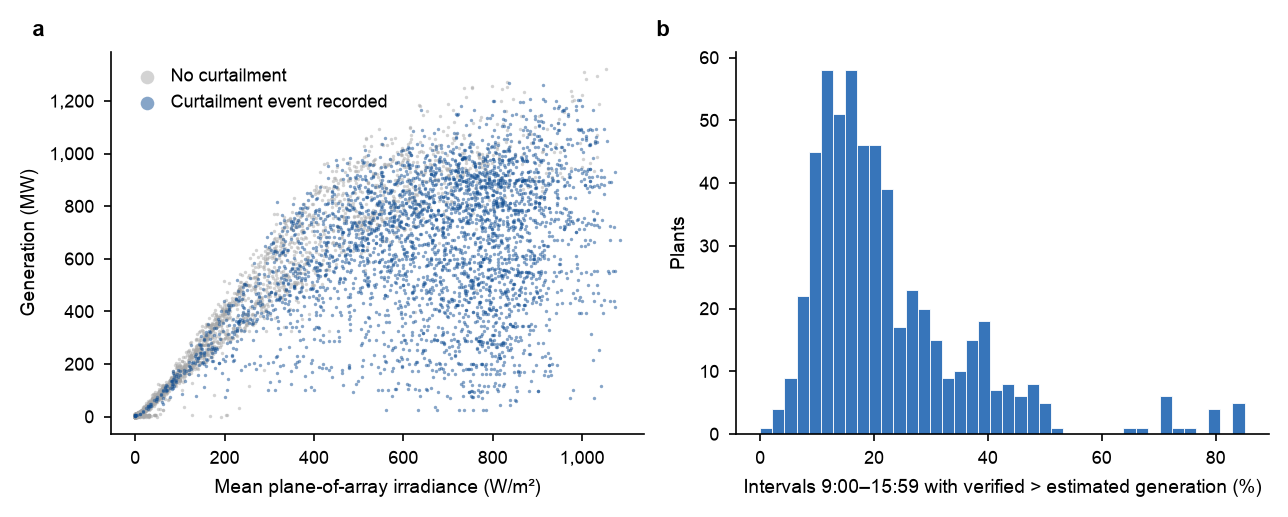

In [14]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=viz.size(height_mm=62), layout="constrained")

# a: irradiance × generation; all intervals, rasterized to keep the PDF light
free = irradiance_vs_generation[~irradiance_vs_generation["is_curtailed"]]
curtailed = irradiance_vs_generation[irradiance_vs_generation["is_curtailed"]]
ax_curve.scatter(free["poa_mean"], free["generation"], s=1.5, color=viz.COLORS["grey"], alpha=0.5,
                 linewidths=0, rasterized=True, label="No curtailment")
ax_curve.scatter(curtailed["poa_mean"], curtailed["generation"], s=1.5, color=viz.COLORS["blue"], alpha=0.5,
                 linewidths=0, rasterized=True, label="Curtailment event recorded")
ax_curve.set_xlabel("Mean plane-of-array irradiance (W/m²)")
ax_curve.set_ylabel("Generation (MW)")
ax_curve.legend(loc="upper left", markerscale=4, handletextpad=0.2)
viz.comma_axis(ax_curve.xaxis)
viz.comma_axis(ax_curve.yaxis)

# b: per-plant distribution of the share of 9:00–15:59 intervals with verified > estimated
ax_hist.hist(plant_quality["verified_above_estimated_pct"].dropna(), bins=40, color=viz.COLORS["blue_mid"],
             edgecolor="white", linewidth=0.3)
ax_hist.set_xlabel("Intervals 9:00–15:59 with verified > estimated generation (%)")
ax_hist.set_ylabel("Plants")

for ax, letter in ((ax_curve, "a"), (ax_hist, "b")):
    viz.panel_label(ax, letter)
viz.save(fig, "fig4_data_quality")

**Figure 4 | Diagnostics of the measurements used for modeling.** **a**, Verified generation against
mean plane-of-array irradiance at the Janaúba cluster, the one with the most curtailed energy,
Jan–Aug 2026 (n = 11,664 30-min intervals, 3,492 with a curtailment event recorded). **b**, Per-plant
distribution of the percentage of 9:00–15:59 intervals in which verified generation exceeds the ONS
estimate (n = 560 plants; 40 bins).

## 6. Conclusions

**Magnitude and trend (Figure 1)**
- The curtailed share nearly doubled: 13.4% (Apr–Dec 2024), 25.7% (2025) and 24.7% (Jan–Aug 2026).
  In 2025, 11.0 TWh were curtailed, against 31.7 TWh generated.
- The reason changed. Energy-balance (ENE, oversupply) curtailment went from 48% of curtailment in 2024
  to 61% in 2025 and 85% in 2026. Electrical-reliability (CNF) curtailment fell from 2.8 TWh in 2025 to
  0.6 TWh in 2026.

**Temporal pattern (Figure 2)**
- Curtailment concentrates between 8:00 and 12:00, with a maximum at 10:00.
- It is higher on weekends: 24–26% on weekdays at 9:00–10:00, 36–37% on Saturday and 58–61% on Sunday.
  The pattern is consistent with the variation of SIN load, analyzed in notebook 02.

**Space (Figure 3)**
- MG (Janaúba, Arinos, Vista Alegre, Jaíba) concentrates the largest volume.
- Among the 20 clusters with the most curtailed energy, the highest shares are in BA: Barreiras II
  500 kV (37%), Sol do Sertão and Ituverava (35%).
- Systemic-origin ENE is the largest component in both the NE (8.0 TWh) and the SE (7.0 TWh). Curtailment
  of local origin is small.

**Quality for modeling (Figure 4)**
- Median of 3% invalid irradiance per plant, but 10% of plants exceed 22%. There are whole days with a
  stuck sensor, mostly in 2024.
- In 22% of daytime intervals, on average, verified generation is above the ONS estimate. The ONS
  estimate should not be used as the true value without calibration.